# **import libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import silhouette_score, r2_score
from mlxtend.frequent_patterns import apriori, association_rules
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.cluster.hierarchy import inconsistent
from scipy.cluster.hierarchy import fcluster
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
 

ModuleNotFoundError: No module named 'xgboost'

# **preprocessing**

### **First, Read the xlsx File**

In [3]:
df = pd.read_excel('d:/dataMining/project/StoresData.xlsx')

### **Get General Informations**

In [6]:
df.shape

(150, 26)

150 row * 26 column

In [9]:
pd.set_option('display.max_columns', None)
df.sample(5)

,Store No.,Sales $m,Wages $m,No. Staff,Location,Loc'n (Num),State,State (Num),Age (Yrs),GrossProfit,Adv.$'000,Competitors,HrsTrading,Sundays,Sundays (Num),Mng-Sex,Mng-Sex (Num),Mng-Age,Mng-Exp,Mng-Train,Union%,Car Spaces,HomeDel,HomeDel (Num),Basket:2013,Basket:2014
51,52,8.7,2.1,53,Strip,1,ACT,8,2,2.872,144,0,73,Sun:Yes,1,Male,0,35,4,3,32,34,Del:No,0,165,171
83,84,8.1,1.9,49,Mall,2,Qld,3,16,0.983,71,2,112,Sun:Yes,1,Male,0,39,7,3,45,23,Del:No,0,175,182
147,148,13.6,2.9,66,Strip,1,WA,5,17,2.620,103,2,102,Sun:No,0,Male,0,39,8,3,45,48,Del:No,0,166,172
148,149,10.0,2.0,55,Mall,2,WA,5,8,1.168,120,3,114,Sun:No,0,Male,0,52,13,3,40,34,Del:No,0,174,182
140,141,6.6,1.7,44,Strip,1,SA,4,2,0.115,70,5,137,Sun:No,0,Male,0,46,7,3,29,19,Del:No,0,161,168


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Store No.      150 non-null    int64  
 1   Sales $m       150 non-null    float64
 2   Wages $m       150 non-null    float64
 3   No. Staff      150 non-null    int64  
 4   Location       150 non-null    object 
 5   Loc'n (Num)    150 non-null    int64  
 6   State          150 non-null    object 
 7   State (Num)    150 non-null    int64  
 8   Age (Yrs)      150 non-null    int64  
 9   GrossProfit    150 non-null    float64
 10  Adv.$'000      150 non-null    int64  
 11  Competitors    150 non-null    int64  
 12  HrsTrading     150 non-null    int64  
 13  Sundays        150 non-null    object 
 14  Sundays (Num)  150 non-null    int64  
 15  Mng-Sex        150 non-null    object 
 16  Mng-Sex (Num)  150 non-null    int64  
 17  Mng-Age        150 non-null    int64  
 18  Mng-Exp   

In [12]:
df['Location'].value_counts()

Location
Mall       61
Strip      51
Country    38
Name: count, dtype: int64

In [15]:
df['State'].value_counts()

State
NSW    40
Vic    30
Qld    27
SA     22
WA     16
ACT     6
Tas     5
NT      4
Name: count, dtype: int64

df['Mng-Sex'].value_counts()

### **Rename columns**

In [19]:
df = df.rename(columns={'Loc\'n (Num)': 'num_Location',
                          'State (Num)':'num_State',
                          'Age (Yrs)':'Age(years)',
                         'Sundays (Num)':'num_Sundays' ,
                          'Mng-Sex (Num)':'num_Mng-Sex',
                         'HomeDel (Num)':'num_HomeDel',
                          'Adv.$\'000':'ADV$000',
                           'Car Spaces':'Car_Spaces',
                           'No. Staff':'No_Staff',
                           'Store No.':'Store_No',
                           'Sales $m':'Sales_$m',
                           'Wages $m':'Wages_$m',
                           'Basket:2013':'Basket2013',
                          'Basket:2014':'Basket2014' })

print(df.columns)

Index(['Store_No', 'Sales_$m', 'Wages_$m', 'No_Staff', 'Location',
       'num_Location', 'State', 'num_State', 'Age(years)', 'GrossProfit',
       'ADV$000', 'Competitors', 'HrsTrading', 'Sundays', 'num_Sundays',
       'Mng-Sex', 'num_Mng-Sex', 'Mng-Age', 'Mng-Exp', 'Mng-Train', 'Union%',
       'Car_Spaces', 'HomeDel', 'num_HomeDel', 'Basket2013', 'Basket2014'],
      dtype='object')


#### **Removing Substring 'Del' from the 'HomeDel' Column and 'Sun' from sundays**


In [22]:
df['HomeDel'] = df['HomeDel'].str.replace('Del:', '', regex=False)

In [24]:
df['Sundays'] = df['Sundays'].str.replace('Sun:', '', regex=False)

### **Check for Missing Values**

In [27]:
df.isna().sum()

Store_No        0
Sales_$m        0
Wages_$m        0
No_Staff        0
Location        0
num_Location    0
State           0
num_State       0
Age(years)      0
GrossProfit     0
ADV$000         0
Competitors     0
HrsTrading      0
Sundays         0
num_Sundays     0
Mng-Sex         0
num_Mng-Sex     0
Mng-Age         0
Mng-Exp         0
Mng-Train       0
Union%          0
Car_Spaces      0
HomeDel         0
num_HomeDel     0
Basket2013      0
Basket2014      0
dtype: int64

no null values

#### **Checking for All Duplicates**

In [31]:
df.duplicated().sum()

0

no duplicates

### **Describing Numeric Columns**

In [35]:
pd.set_option('display.max_columns', None)

df.describe()

,Store_No,Sales_$m,Wages_$m,No_Staff,num_Location,num_State,Age(years),GrossProfit,ADV$000,Competitors,HrsTrading,num_Sundays,num_Mng-Sex,Mng-Age,Mng-Exp,Mng-Train,Union%,Car_Spaces,num_HomeDel,Basket2013,Basket2014
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,11.659333,2.376667,61.493333,1.913333,3.033333,8.846667,1.009953,147.273333,2.506667,106.353333,0.620000,0.166667,38.420000,9.253333,2.813333,37.786667,44.186667,0.300000,171.806667,178.846667
std,43.445368,3.570989,0.567866,14.605206,0.767954,1.894594,5.442483,0.645794,67.994265,1.744586,23.676550,0.487013,0.373927,7.337748,3.985185,1.183707,4.899783,22.162725,0.459793,8.005616,8.637158
min,1.000000,5.900000,1.500000,35.000000,1.000000,1.000000,1.000000,0.018000,20.000000,0.000000,72.000000,0.000000,0.000000,27.000000,1.000000,1.000000,24.000000,8.000000,0.000000,156.000000,162.000000
25%,38.250000,8.825000,1.900000,51.000000,1.000000,1.000000,4.250000,0.511000,101.000000,1.000000,87.250000,0.000000,0.000000,33.000000,7.000000,2.000000,35.000000,26.000000,0.000000,164.000000,171.000000
50%,75.500000,10.950000,2.200000,58.000000,2.000000,3.000000,7.500000,0.975000,130.500000,2.000000,101.000000,1.000000,0.000000,37.000000,9.000000,3.000000,38.000000,39.500000,0.000000,172.000000,179.000000
75%,112.750000,14.000000,2.700000,69.750000,2.750000,4.000000,12.000000,1.415000,196.750000,4.000000,120.750000,1.000000,0.000000,43.000000,12.000000,3.000000,41.000000,58.000000,1.000000,178.000000,185.000000
max,150.000000,23.500000,3.900000,117.000000,3.000000,8.000000,24.000000,2.872000,369.000000,7.000000,168.000000,1.000000,1.000000,61.000000,21.000000,6.000000,50.000000,114.000000,1.000000,201.000000,204.000000


In [37]:
numeric_cols=df.select_dtypes(include=['number'])
numeric_col = numeric_cols.drop(columns=['num_Location', 'num_State'])

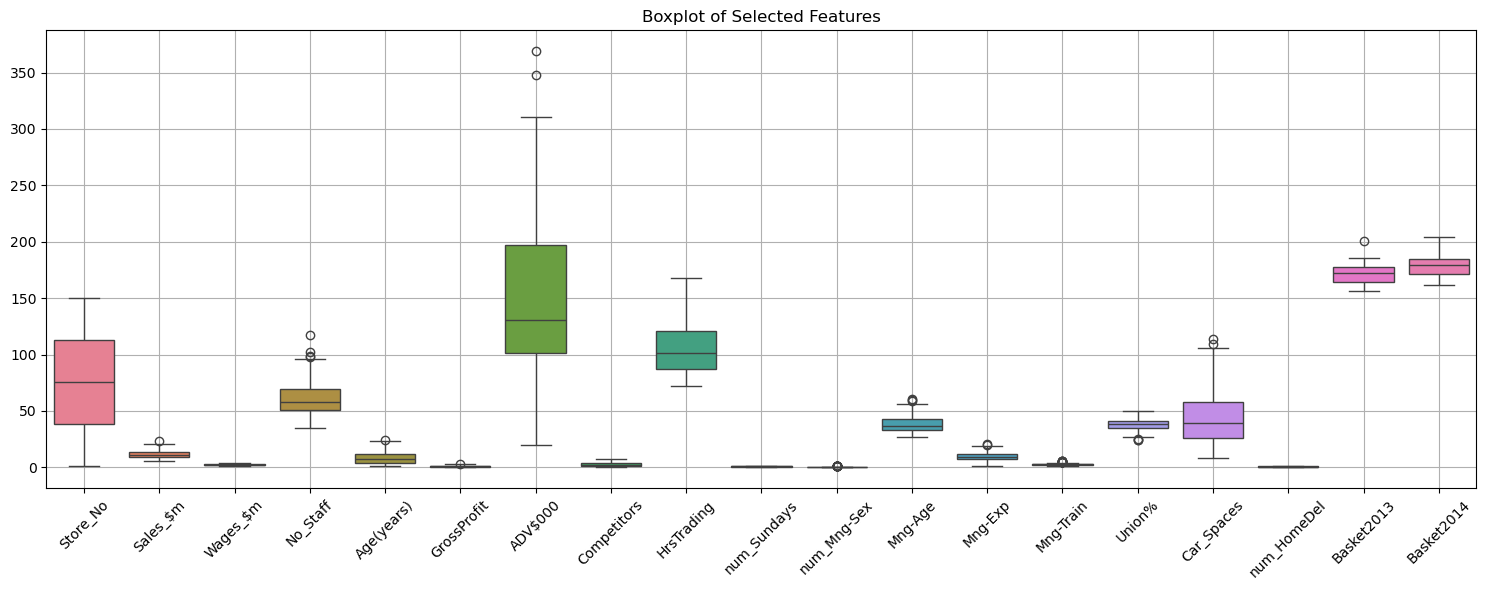

In [39]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=numeric_col)
plt.xticks(rotation=45)
plt.title('Boxplot of Selected Features')
plt.grid(True)
plt.tight_layout()
plt.show()

check coulmns wich have outliers by box blot 

In [41]:
x = df[['No_Staff', 'Sales_$m', 'GrossProfit', "ADV$000", 'Mng-Exp', 'Car_Spaces','Age(years)','Basket2013','Mng-Train','Mng-Age','Union%']]

for i in x.columns:
    Q1 = x[i].quantile(0.25)
    Q3 = x[i].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df = df[(df[i] >= lower_bound) & (df[i] <= upper_bound)]


# **visuaLization**

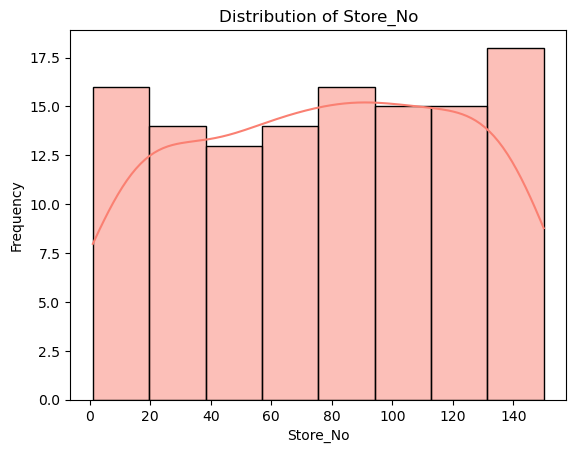

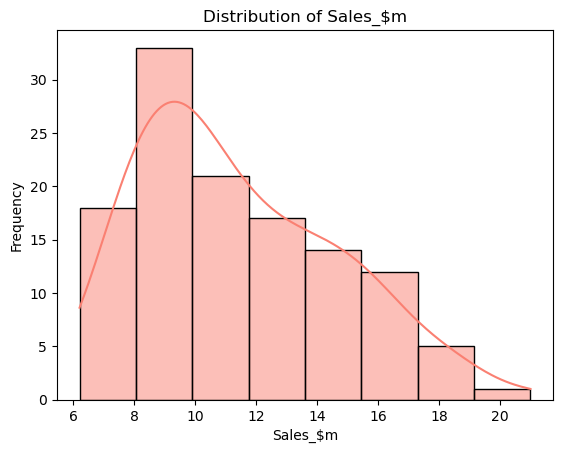

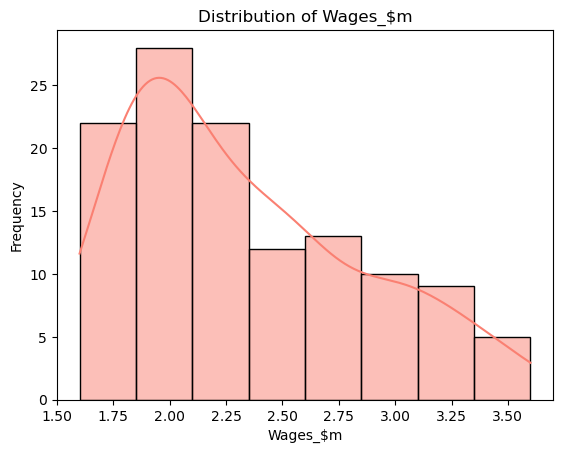

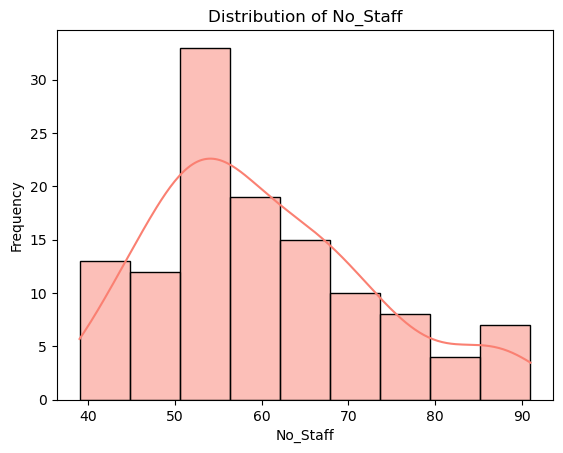

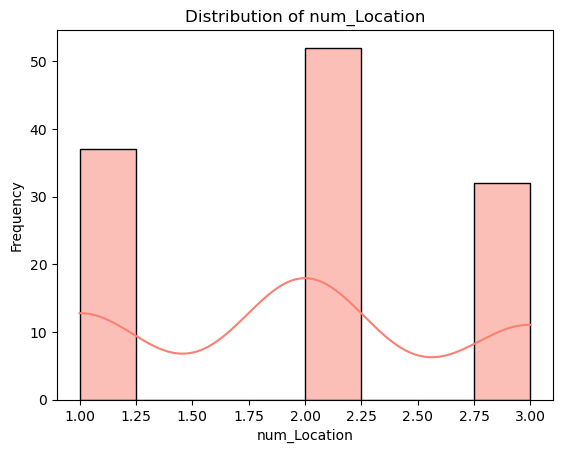

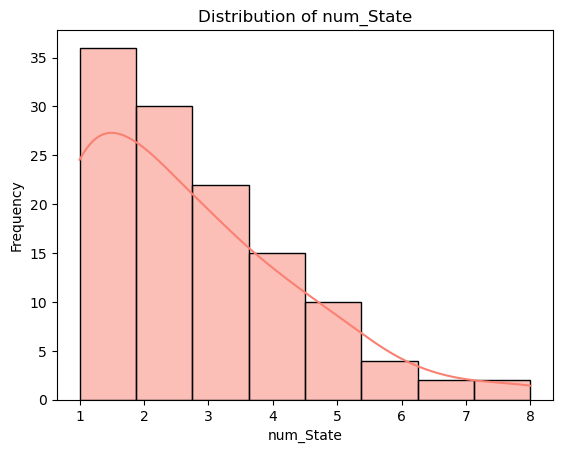

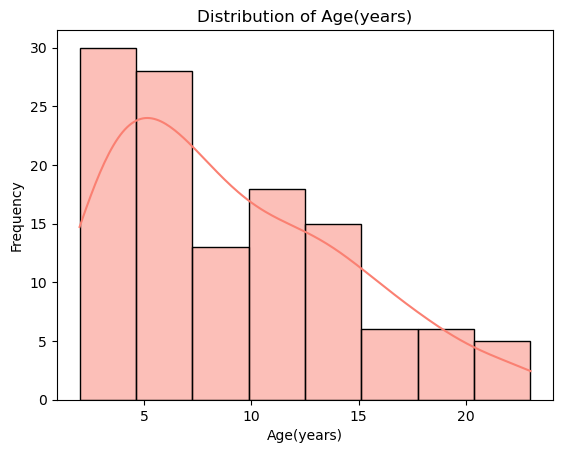

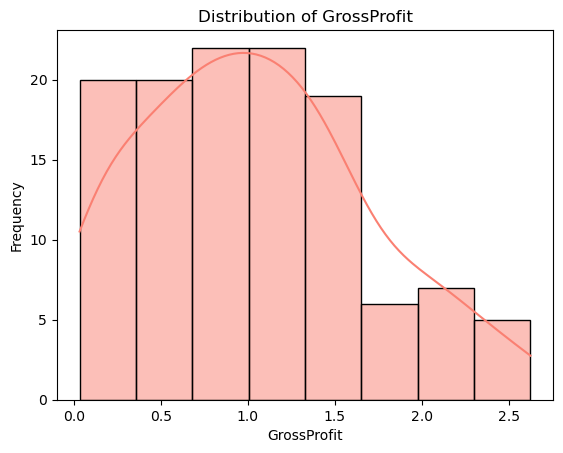

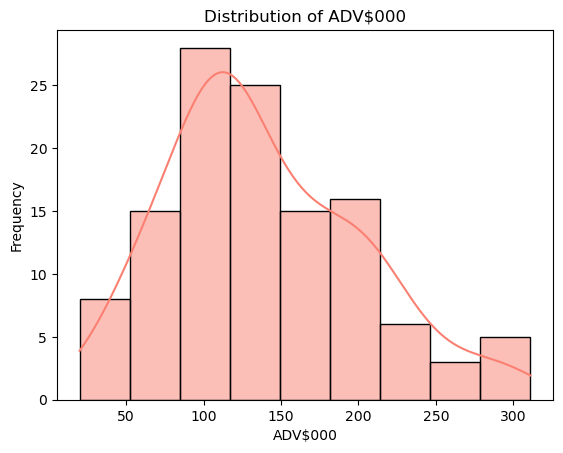

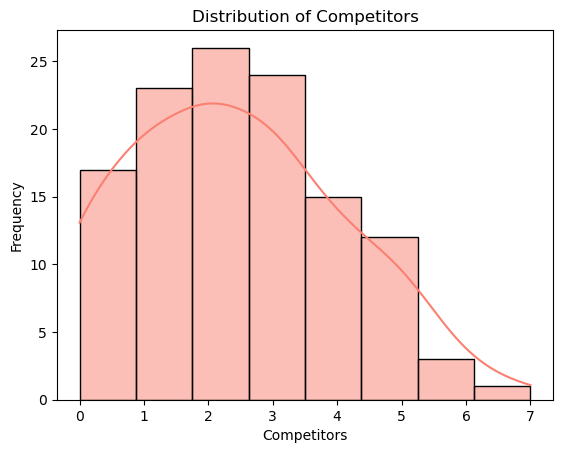

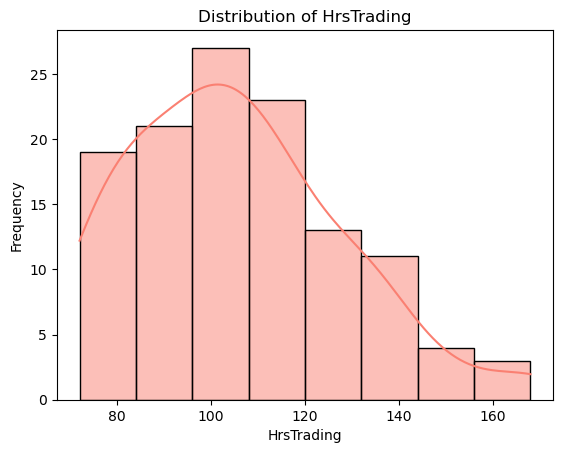

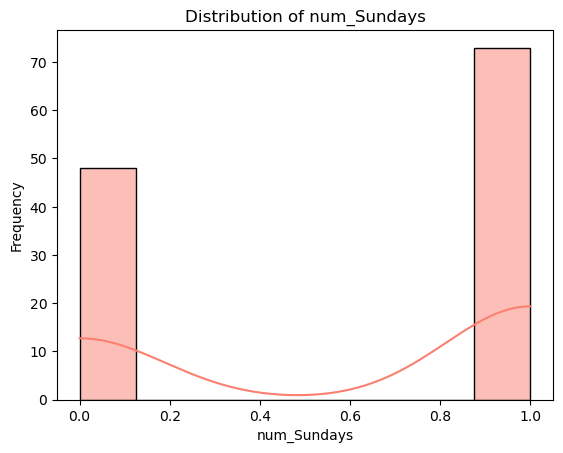

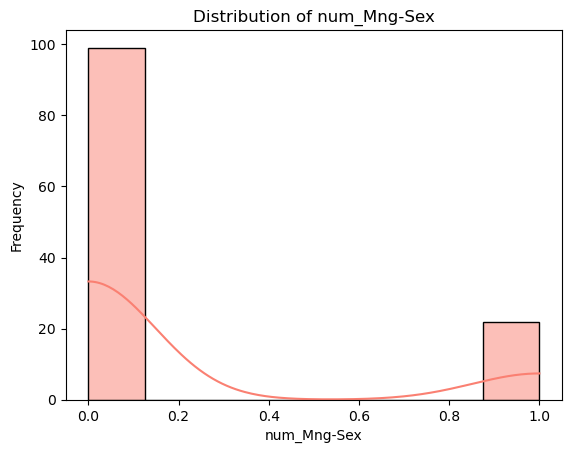

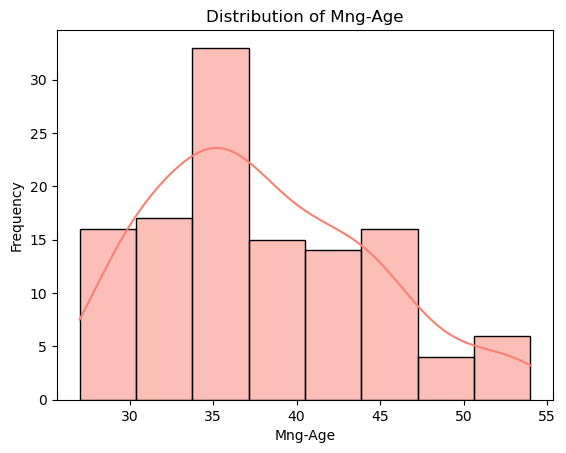

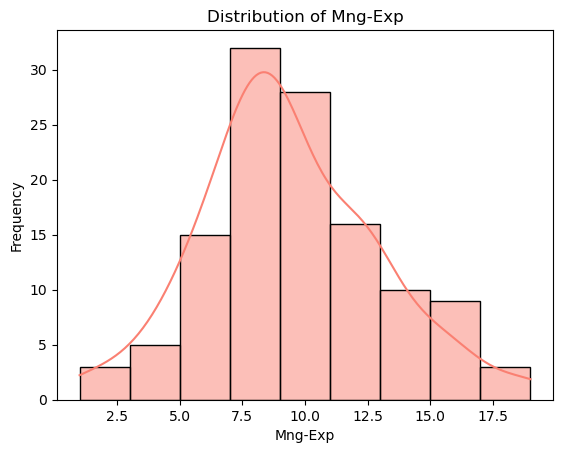

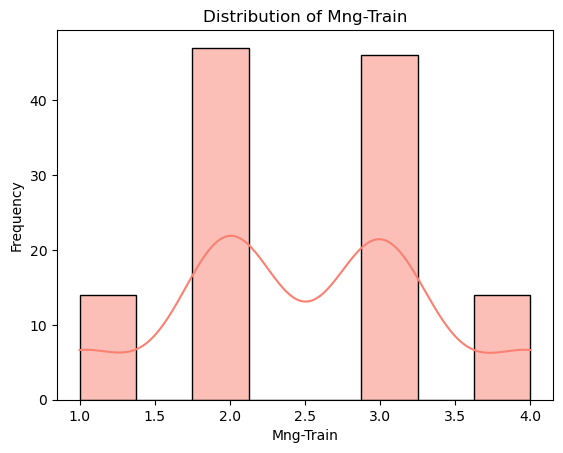

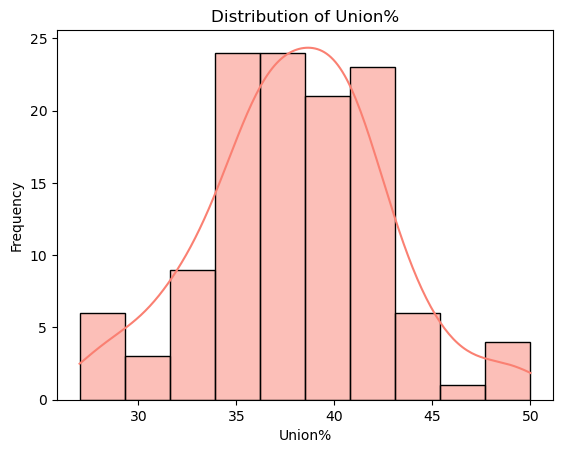

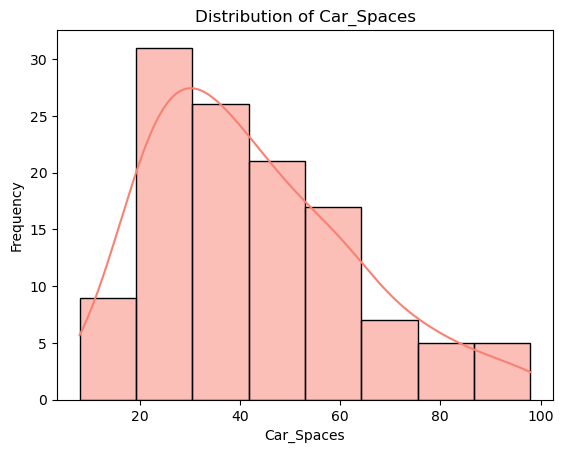

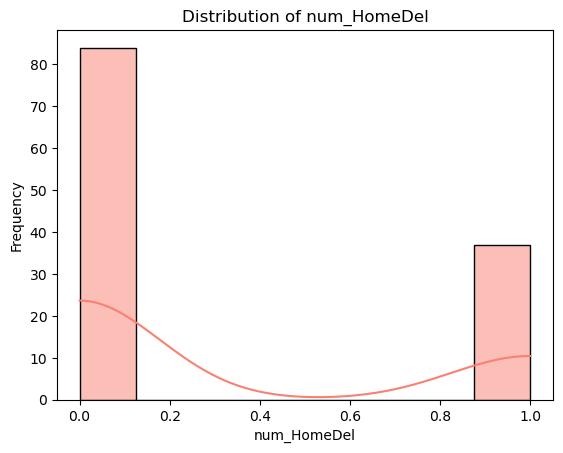

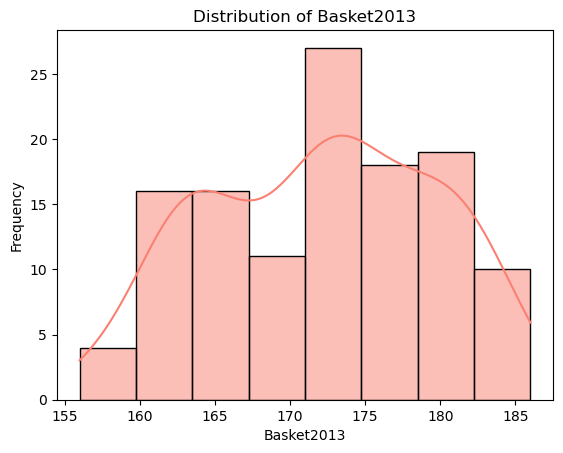

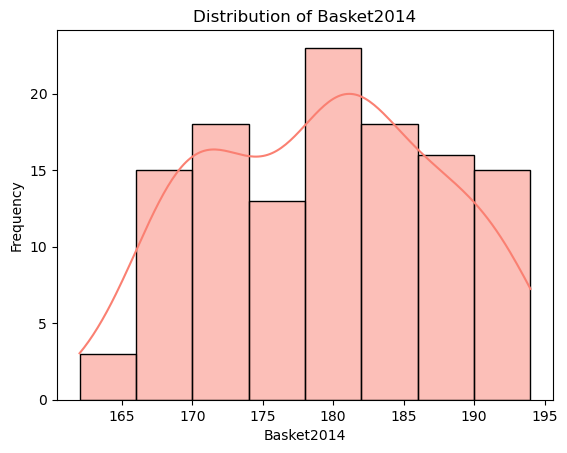

In [45]:
for col in numeric_cols:
    sns.histplot(df[col], kde=True,color='salmon',edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

histograms to show us the distribution of our columns using kde 

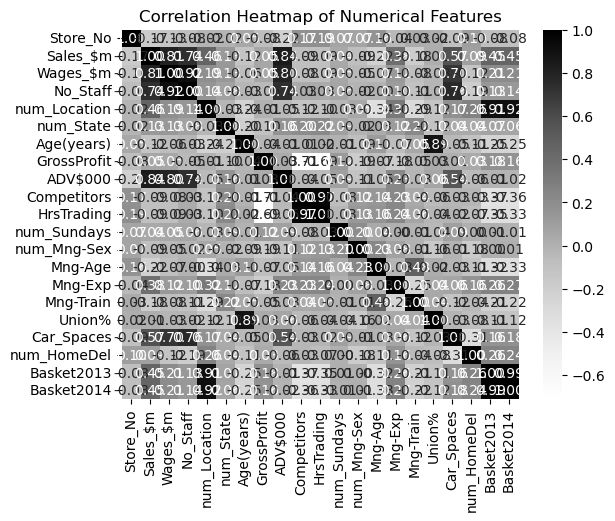

In [47]:
sns.heatmap(numeric_cols.corr(), annot=True, cmap='Greys', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

correlation heat map to show us the how strong the relation ship between features
* between basket 2013&2014&num-location  very strong relation ship we can use only one of them
* same  between competetors & hrs_traiding
* same between no_stuff & wages

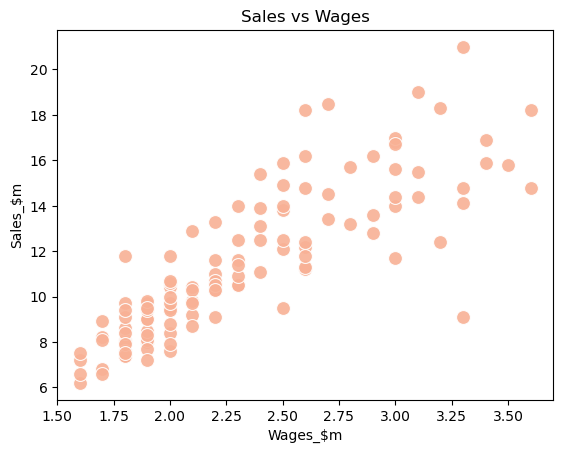

In [49]:
sns.scatterplot(x='Wages_$m', y='Sales_$m', data=df, color='#F8B195',s=100,alpha=0.9)
plt.title('Sales vs Wages')
plt.show()

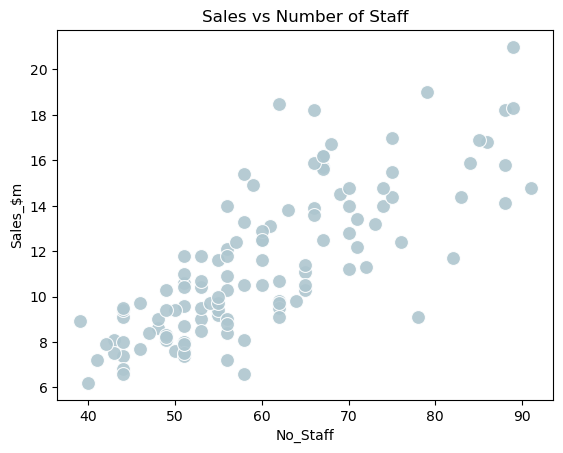

In [50]:
sns.scatterplot(x='No_Staff', y='Sales_$m', data=df, color='#AEC6CF',s=100,alpha=0.9)
plt.title('Sales vs Number of Staff')
plt.show()

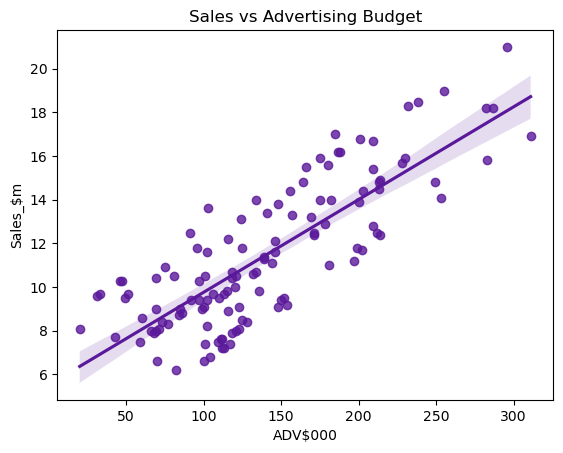

In [51]:
sns.regplot(x='ADV$000', y='Sales_$m', data=df,color='#5A189A')
plt.title('Sales vs Advertising Budget')
plt.show()

C:\Users\paragon\AppData\Local\Temp\ipykernel_10140\2535076990.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='num_State', y='GrossProfit', data=df,palette='coolwarm')


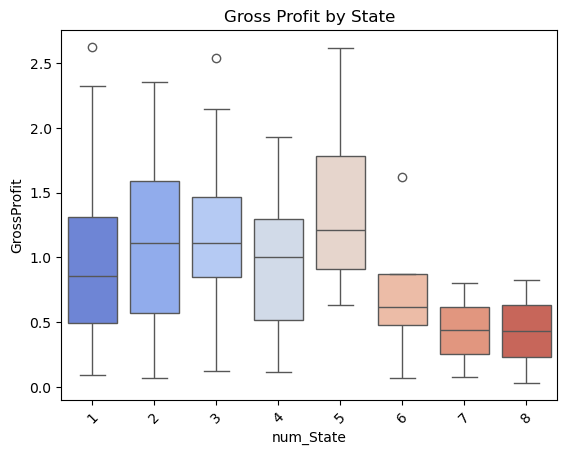

In [52]:
sns.boxplot(x='num_State', y='GrossProfit', data=df,palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Gross Profit by State')
plt.show()

*top Grossprofit in state2
*top median profit in state3 then 2&5
*outliers in state 3,5,8
*the least grossprofits in state 8
*the most gross profit we have achived in state 1

C:\Users\paragon\AppData\Local\Temp\ipykernel_10140\2024743313.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='num_Mng-Sex', y='Mng-Age', data=df,palette='rocket')


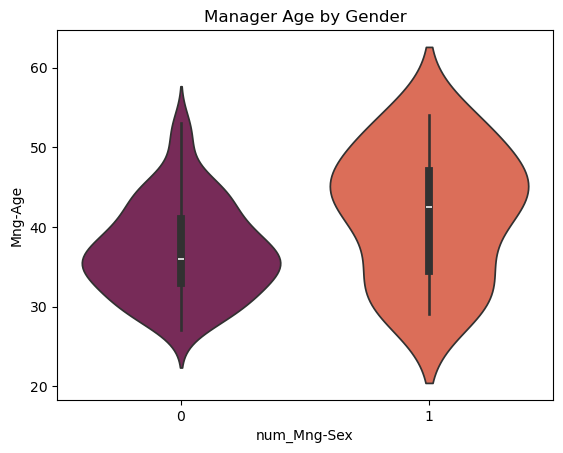

In [54]:
sns.violinplot(x='num_Mng-Sex', y='Mng-Age', data=df,palette='rocket')
plt.title("Manager Age by Gender")
plt.show()

*num of females less than males
*age of females less than males

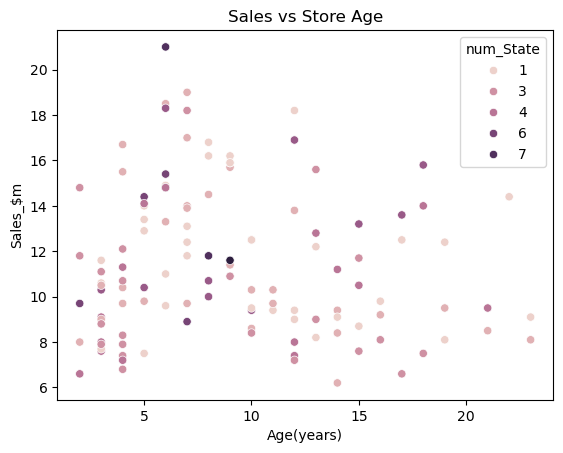

In [56]:
sns.scatterplot(x='Age(years)', y='Sales_$m', data=df,color='#6E6E6E', hue='num_State')
plt.title('Sales vs Store Age')
plt.show()

sales of new stores are more than old stores

C:\Users\paragon\AppData\Local\Temp\ipykernel_10140\1509268228.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['Basket2013'], label='2013', shade=True)
C:\Users\paragon\AppData\Local\Temp\ipykernel_10140\1509268228.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['Basket2014'], label='2014', shade=True)


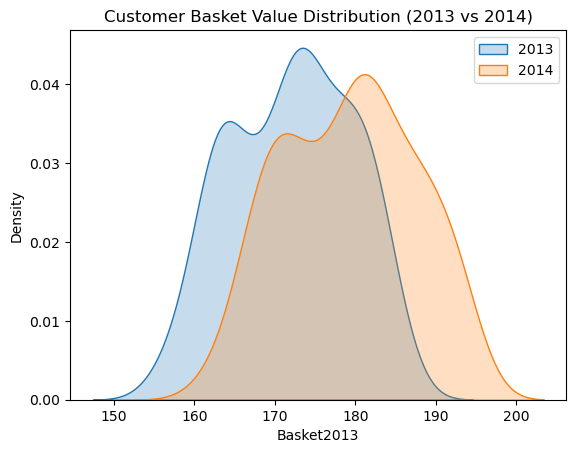

In [58]:
sns.kdeplot(df['Basket2013'], label='2013', shade=True)
sns.kdeplot(df['Basket2014'], label='2014', shade=True)
plt.title('Customer Basket Value Distribution (2013 vs 2014)')
plt.legend()
plt.show()

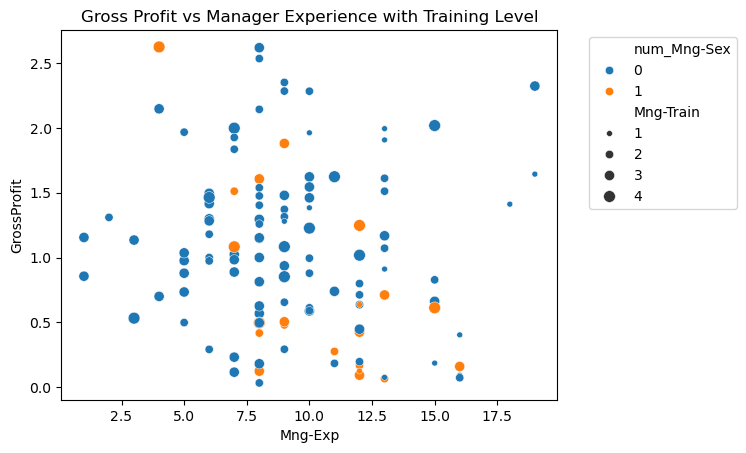

In [60]:
sns.scatterplot(x='Mng-Exp', y='GrossProfit', size='Mng-Train', data=df, hue='num_Mng-Sex')
plt.title('Gross Profit vs Manager Experience with Training Level')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

no reltionship between profit and years of experience

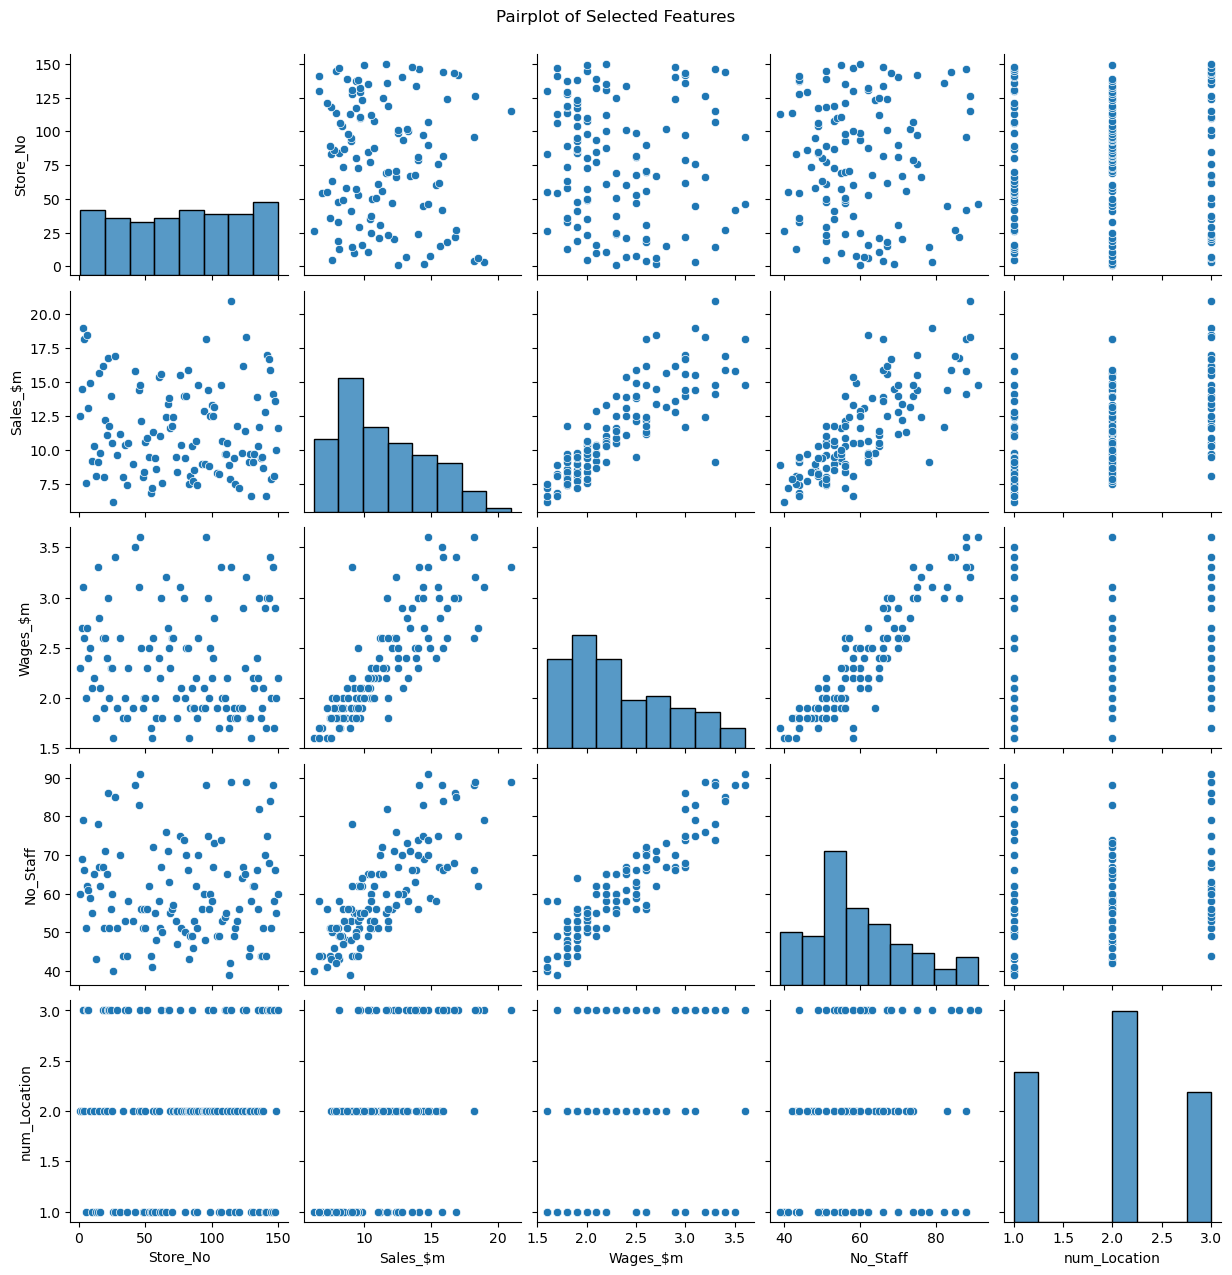

In [62]:
my_cols = df.select_dtypes(include='number').columns[:5]

sns.pairplot(df[my_cols])

plt.suptitle('Pairplot of Selected Features', y=1.02)
plt.show()

In [65]:
df.groupby('num_Sundays')['GrossProfit'].mean()

num_Sundays
0    0.936500
1    1.112918
Name: GrossProfit, dtype: float64

profits of stores witch opend on sundays are more than closed stores 

In [70]:
df.groupby('num_HomeDel')['GrossProfit'].mean()

num_HomeDel
0    1.022298
1    1.089784
Name: GrossProfit, dtype: float64

In [72]:
df.sample()

,Store_No,Sales_$m,Wages_$m,No_Staff,Location,num_Location,State,num_State,Age(years),GrossProfit,ADV$000,Competitors,HrsTrading,Sundays,num_Sundays,Mng-Sex,num_Mng-Sex,Mng-Age,Mng-Exp,Mng-Train,Union%,Car_Spaces,HomeDel,num_HomeDel,Basket2013,Basket2014
131,132,9.7,2.1,62,Mall,2,Vic,2,11,1.152,106,2,96,Yes,1,Male,0,42,8,3,42,49,No,0,171,178


profits of stores witch provides delevery is more

# **Sales Prediction Using Multiple Linear Regression: Understanding Customer Preferences**

In [77]:
df = df.drop(['Location', 'State', 'Sundays','Mng-Sex','HomeDel',''], axis=1,errors='ignore')
correlation = df.corr()
print(correlation['Sales_$m'].sort_values(ascending=False))

Sales_$m        1.000000
Wages_$m        0.836738
ADV$000         0.812669
No_Staff        0.779662
Car_Spaces      0.626613
num_Location    0.452996
Basket2014      0.447666
Basket2013      0.443977
Mng-Exp         0.332634
GrossProfit     0.153992
num_Sundays     0.086614
num_HomeDel     0.086237
num_State       0.057733
Union%          0.000595
Store_No       -0.100659
Age(years)     -0.105008
num_Mng-Sex    -0.117625
Competitors    -0.127181
HrsTrading     -0.131777
Mng-Age        -0.266578
Mng-Train      -0.307265
Name: Sales_$m, dtype: float64


In [78]:
X = df[['Wages_$m','No_Staff','ADV$000','Car_Spaces','num_Location']]
y = df['Sales_$m']

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  random_state=42)

In [81]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [82]:
regr = linear_model.LinearRegression()
regr.fit(X_train, y_train)

LinearRegression()

In [83]:
y_pred = regr.predict(X_test)


In [84]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
  
 
print("\nIntercept:", regr.intercept_)
print("\nMean Squared Error (MSE):", mse)
 
print("\nR2 Score:", r2)


Intercept: 0.34172388543804644

Mean Squared Error (MSE): 1.4473390973226785

R2 Score: 0.8925625338996261


In [85]:
coefficients = regr.coef_
coeff_df = pd.DataFrame({
    'Feature': X.columns,  
    'Coefficient': coefficients  
})
coeff_df = coeff_df.sort_values(by='Coefficient', ascending=False)
coeff_df

,Feature,Coefficient
4,num_Location,2.261562
0,Wages_$m,0.664931
2,ADV$000,0.042187
3,Car_Spaces,0.006630
1,No_Staff,-0.017888


In [86]:
#Location, wages, and home delivery:

#Location: Stores located in popular or strategic locations (such as shopping centers) tend to drive higher sales. In other words, having the store in a prime location attracts more customers.

#Wages: Higher wages for employees may lead to better performance in the store and higher sales. This could be because well-paid employees are generally more motivated and efficient.

#--------------Advertising:

#Spending more on advertising helps to raise brand awareness and attract more customers, which in turn leads to an increase in sales.


#Number of staff: This factor has a minimal effect on sales. While having more staff might improve service, it isn't the primary driver of sales.

#Car spaces: More parking spaces make it easier for customers to visit the store, but this factor has a relatively weak impact on sales.


#  **Customer Segmentation Analysis: Unveiling Consumer Behavior Across Store Locations using K-means**

In [88]:
cor=numeric_cols.corr()
maxi = ( cor.abs() > 0.7)
maxi

,Store_No,Sales_$m,Wages_$m,No_Staff,num_Location,num_State,Age(years),GrossProfit,ADV$000,Competitors,HrsTrading,num_Sundays,num_Mng-Sex,Mng-Age,Mng-Exp,Mng-Train,Union%,Car_Spaces,num_HomeDel,Basket2013,Basket2014
Store_No,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
Sales_$m,False,True,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
Wages_$m,False,True,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False
No_Staff,False,True,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False
num_Location,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
num_State,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
Age(years),False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False
GrossProfit,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False
ADV$000,False,True,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
Competitors,False,False,False,False,False,False,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False


d:\python\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\python\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\python\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\python\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there a

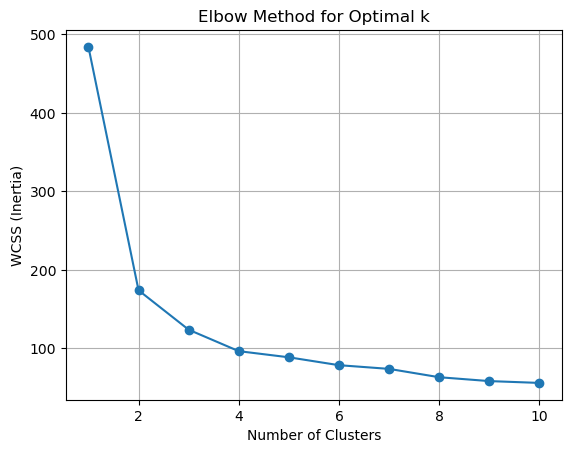

In [89]:
features = ['Sales_$m', 'Wages_$m', 'ADV$000', 'No_Staff']
X = df[features]
X_scaled = StandardScaler().fit_transform(X)

wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  

plt.plot(K_range, wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

In [137]:
from sklearn.preprocessing import StandardScaler
#features = ['Sales_$m', 'Wages_$m', 'ADV$000', 'No_Staff']

#behavior_features = df[features].dropna()


In [138]:
scaler = StandardScaler()
behavior_scaled = scaler.fit_transform(behavior_features)

In [109]:
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled_df)
X_scaled_df['Customer_Segment'] =clusters

d:\python\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [111]:
from sklearn.metrics import silhouette_score, r2_score
silhouette = silhouette_score(X_scaled_df[features], clusters)
print(f"Silhouette Score: {silhouette:.2f}")


Silhouette Score: 0.53


model evaluated by silhoutte score

In [114]:
segment_profiles = behavior_scaled_df.groupby('Customer_Segment').mean()
segment_profiles

,Sales_$m,Wages_$m,ADV$000,No_Staff
Customer_Segment,,,,
0,1.050759,1.128504,1.027831,1.024745
1,-0.600433,-0.644860,-0.587332,-0.585568


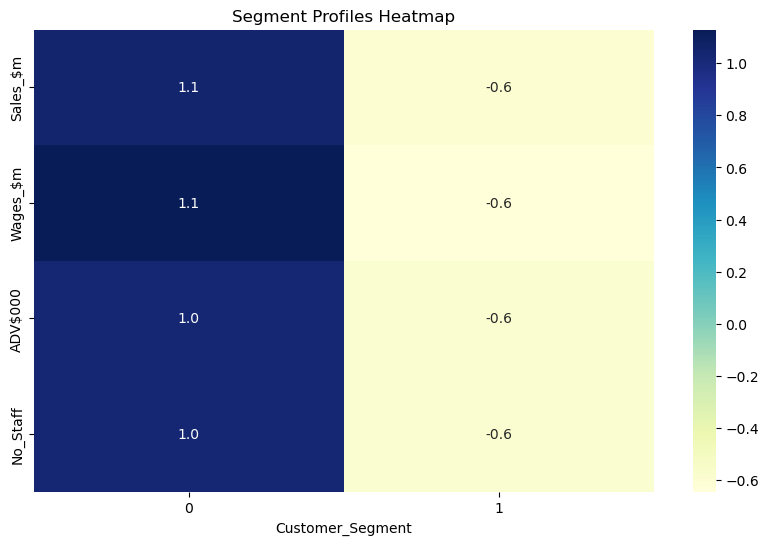

In [116]:
plt.figure(figsize=(10, 6))
sns.heatmap(segment_profiles.T, cmap='YlGnBu', annot=True, fmt='.1f')
plt.title('Segment Profiles Heatmap')
plt.show()

#Customer Segments Summary
You applied clustering on four features:
Sales ($m), Wages ($m), Advertising ($000), and Number of Staff.

Segment 0 – High-Value Stores
These stores have above-average values in all selected features.

They spend more on wages and advertising.

They have more staff and generate higher sales.

Segment 1 – Lower-Value Stores
These stores have below-average values across all metrics.

They are likely smaller, spend less on wages and advertising, and generate lower sales.

# **Exploring Customer Behavior: A Focus on Home Delivery, Advertising, and Store Locations – Insights from Apriori Analysis**


In [118]:
A=df[['num_HomeDel', 'num_Location']]

In [120]:
location_dummies = pd.get_dummies(A['num_Location'], prefix='Location')
data_encoded = pd.concat([A[['num_HomeDel']], location_dummies], axis=1)
data_encoded

,num_HomeDel,Location_1,Location_2,Location_3
0,0,False,True,False
1,0,False,True,False
2,0,False,False,True
3,1,False,True,False
4,0,True,False,False
...,...,...,...,...
145,0,True,False,False
146,0,False,False,True
147,0,True,False,False
148,0,False,True,False


In [122]:
frequent_itemsets = apriori(data_encoded, min_support=0.05, use_colnames=True)
frequent_itemsets.head()

d:\python\anaconda\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.305785,(num_HomeDel)
1,0.305785,(Location_1)
2,0.429752,(Location_2)
3,0.264463,(Location_3)
4,0.057851,"(Location_1, num_HomeDel)"


In [124]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1, num_itemsets=len(frequent_itemsets))

In [126]:
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]


,antecedents,consequents,support,confidence,lift
0,(Location_2),(num_HomeDel),0.132231,0.307692,1.006237
1,(num_HomeDel),(Location_2),0.132231,0.432432,1.006237
2,(Location_3),(num_HomeDel),0.115702,0.437500,1.430743
3,(num_HomeDel),(Location_3),0.115702,0.378378,1.430743


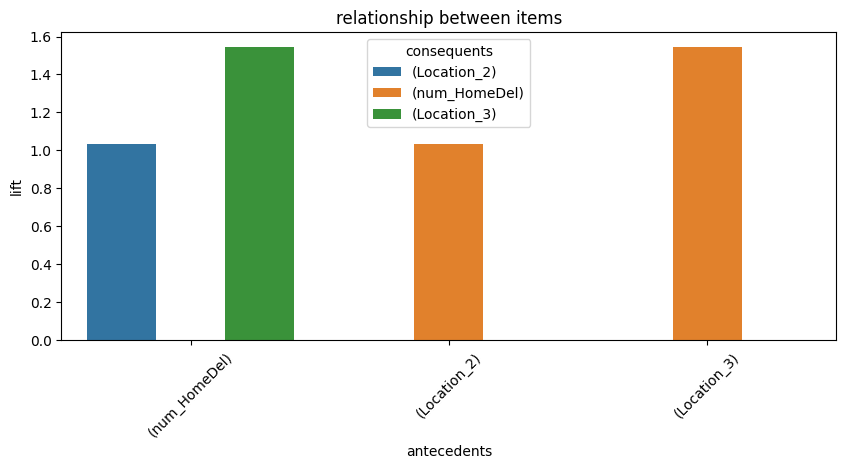

In [149]:
rules = pd.DataFrame({
    'antecedents': ['(num_HomeDel)', '(Location_2)', '(Location_3)', '(num_HomeDel)'],
    'consequents': ['(Location_2)', '(num_HomeDel)', '(num_HomeDel)', '(Location_3)'],
    'support': [0.129, 0.129, 0.122, 0.122],
    'confidence': [0.422, 0.317, 0.474, 0.400],
    'lift': [1.034, 1.034, 1.547, 1.547]
})


plt.figure(figsize=(10, 4))
sns.barplot(data=rules, x='antecedents', y='lift', hue='consequents')
plt.title('relationship between items')
plt.xticks(rotation=45)
plt.show()

--------Customer Behavior:
The findings suggest that home delivery is more likely to be associated with certain store locations (Location_2 and Location_3), indicating that customers in these areas may have a stronger preference for home delivery.

------Targeted Marketing:
By identifying these relationships, you could tailor marketing efforts to promote home delivery in areas with higher associations (like Location_3). For example, advertising home delivery services more heavily in stores located in Location_3 might drive more traffic and sales.

--------Inventory and Service Improvements:
Knowing which locations offer home delivery, you can optimize inventory management and ensure that delivery services are in line with customer expectations for those areas. Location-based promotions and customer service strategies could be refined accordingly

# *hierarichal clustring*

In [150]:
variance=numeric_cols.var()
sorted_variance=variance.sort_values(ascending=False)
top_features= sorted_variance.head(10)
top_features

ADV$000       4623.220089
Store_No      1887.500000
HrsTrading     560.579016
Car_Spaces     491.186398
No_Staff       213.312036
Basket2014      74.600492
Basket2013      64.089888
Mng-Age         53.842550
Age(years)      29.620626
Union%          24.007875
dtype: float64

In [151]:



features = ['ADV$000', 'Store_No', 'HrsTrading', 'Car_Spaces','No_Staff']

data = df[features].dropna()

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

linked = linkage(data_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, labels=df.index.tolist(), orientation='top', distance_sort='ascending')
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

NameError: name 'linkage' is not defined

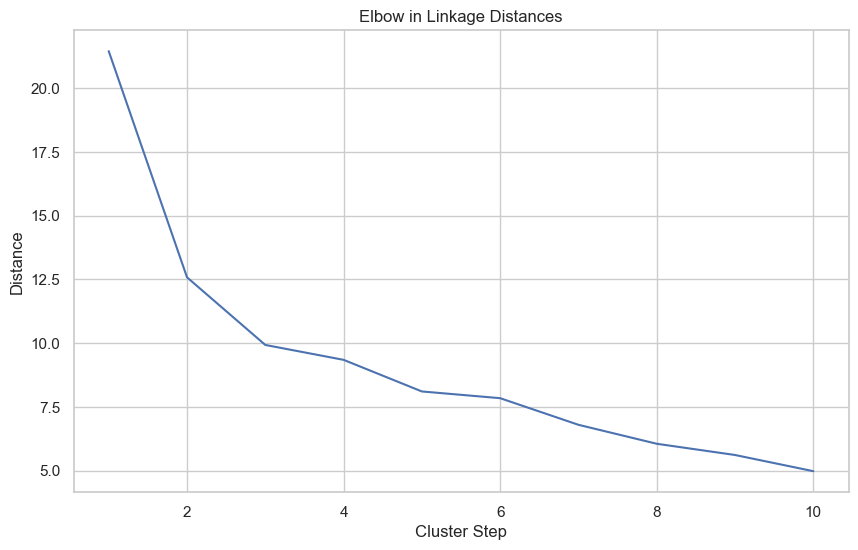

In [ ]:


linked = linkage(data_scaled, method='ward')

depth = 5  
incons = inconsistent(linked, depth)

last = linked[-10:, 2]  
plt.plot(range(1, 11), last[::-1])
plt.title('Elbow in Linkage Distances')
plt.xlabel('Cluster Step')
plt.ylabel('Distance')
plt.show()

best num of clusters is 2

In [ ]:
from scipy.cluster.hierarchy import fcluster
labels = fcluster(linked, t=2, criterion='maxclust')

In [ ]:
from sklearn.metrics import silhouette_score
score = silhouette_score(data_scaled, labels)
print(f"Silhouette Score: {score}")

Silhouette Score: 0.3243415245870134


good evaluation between 0.3 & 0.5

# **RandomForestRegressor**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

X_cust = df[['ADV$000', 'Age(years)']].dropna()
y_cust = df.loc[X_cust.index, 'Basket2014']
X_train, X_test, y_train, y_test = train_test_split(X_cust, y_cust, test_size=0.3)

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: ${mae:,.0f}")



MAE: $8


Applying non linear regression using random forest

In [ ]:
mean_actual = y_test.mean()

mae_percent = (mae / mean_actual) * 100

print(f"MAE: ${mae:,.2f}")
print(f"Average Basket Size: ${mean_actual:,.2f}")
print(f"MAE Percentage of Average: {mae_percent:.2f}%")

MAE: $8.24
Average Basket Size: $180.14
MAE Percentage of Average: 4.57%


very good model with no bias because mae less than 10% from average Basket size

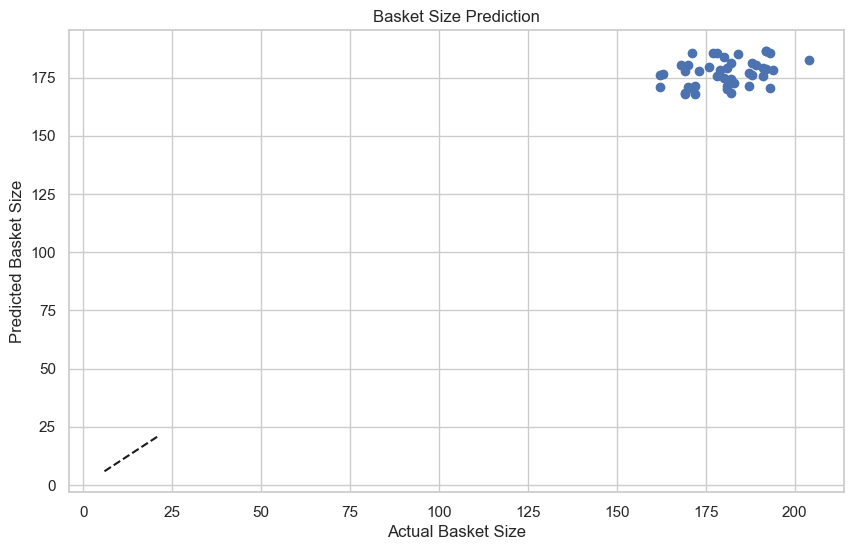

In [ ]:
plt.scatter(y_test, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--')
plt.xlabel('Actual Basket Size')
plt.ylabel('Predicted Basket Size')
plt.title('Basket Size Prediction')
plt.show()

#  **XGBClassifier**

In [ ]:
 

le = LabelEncoder()
df['Sundays-encoded'] = le.fit_transform(df['Sundays'])


X_class = df[['Competitors', 'num_State', 'num_Location','Age(years)','HrsTrading', 'Union%','GrossProfit','Sales_$m','No_Staff','Basket2014']].dropna()
y_class = df.loc[X_class.index, 'num_Sundays-encoded']

X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.3, random_state=42)
                                                    
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

model = XGBClassifier(eval_metric='logloss', random_state=42)
model.fit(X_train_bal, y_train_bal)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

          No       0.43      0.46      0.44        13
         Yes       0.77      0.75      0.76        32

    accuracy                           0.67        45
   macro avg       0.60      0.61      0.60        45
weighted avg       0.67      0.67      0.67        45



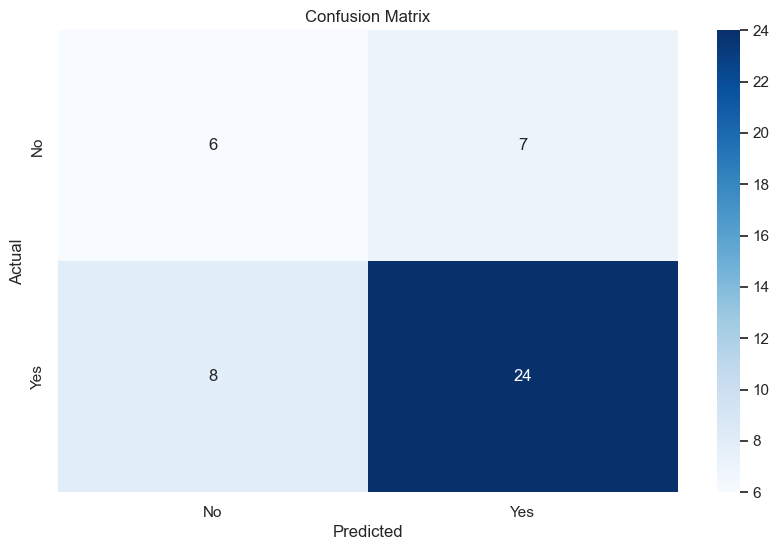

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# **XGBClassifier**

In [ ]:
 

le = LabelEncoder()
df['Mng-Sex_encoded'] = le.fit_transform(df['Mng-Sex'])  

X_class = df[['Mng-Age', 'Mng-Exp', 'Union%']].dropna()
y_class = df.loc[X_class.index, 'Mng-Sex_encoded']

X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.3, random_state=42)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train_bal, y_train_bal)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))


              precision    recall  f1-score   support

      Female       0.30      0.43      0.35         7
        Male       0.89      0.82      0.85        38

    accuracy                           0.76        45
   macro avg       0.59      0.62      0.60        45
weighted avg       0.79      0.76      0.77        45



D:\NF\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:54:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


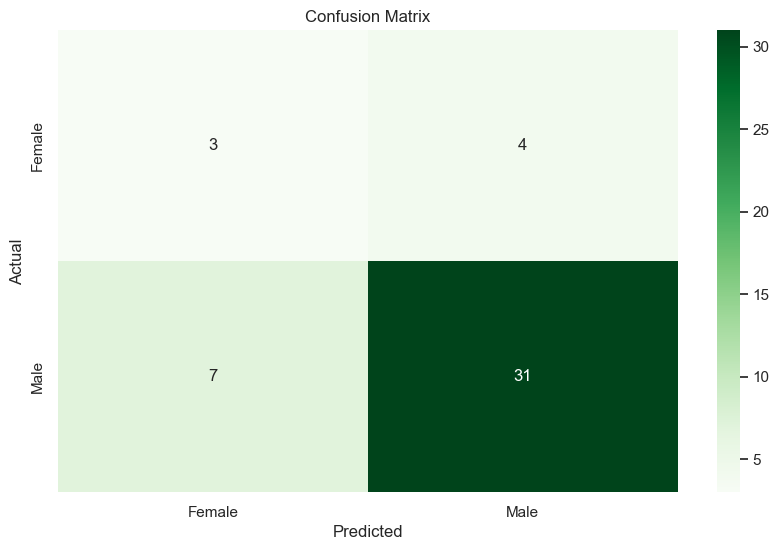

In [ ]:
 

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()